<img src="image.png" width="2000" height="450" />


## Introduction

This assignment is on applying Multiple Minimum Support, a form of Apriori, and an Association Mining Technique to find rules in transactions. The data is from fm music on popular artists before the 2010s. 


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations

## Required Preprocessing [8 Marks]

#### 1. Load user_artists.dat (columns: userID, artistID, weight/playcount) and merge with artists.dat for
names.

In [26]:
df = pd.read_csv('data/user_artists.dat', sep='\t')

In [27]:
df.head()

,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [28]:
# merge with artist data to get artist names
artist_df = pd.read_csv('data/artists.dat', sep='\t')


In [29]:
artist_df.head(5)


,id,name,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [30]:
# change id to artist_id for merging
artist_df.rename(columns={'id': 'artistID'}, inplace=True)

In [31]:

merged_df = pd.merge(df, artist_df, on='artistID')

In [69]:
merged_df.head()

,userID,artistID,weight,name,url,pictureURL
0,2,51,13883,Duran Duran,http://www.last.fm/music/Duran+Duran,http://userserve-ak.last.fm/serve/252/155668.jpg
1,2,52,11690,Morcheeba,http://www.last.fm/music/Morcheeba,http://userserve-ak.last.fm/serve/252/46005111...
2,2,53,11351,Air,http://www.last.fm/music/Air,http://userserve-ak.last.fm/serve/252/251119.jpg
3,2,54,10300,Hooverphonic,http://www.last.fm/music/Hooverphonic,http://userserve-ak.last.fm/serve/252/40553471...
4,2,55,8983,Kylie Minogue,http://www.last.fm/music/Kylie+Minogue,http://userserve-ak.last.fm/serve/252/12740835...


####  2. Define one transaction per user: the set of artists that user listened to above a playcount threshold. 

Choose your threshold, justify it with a histogram, and report: total transactions,
unique items, average transaction length, top 15 items.

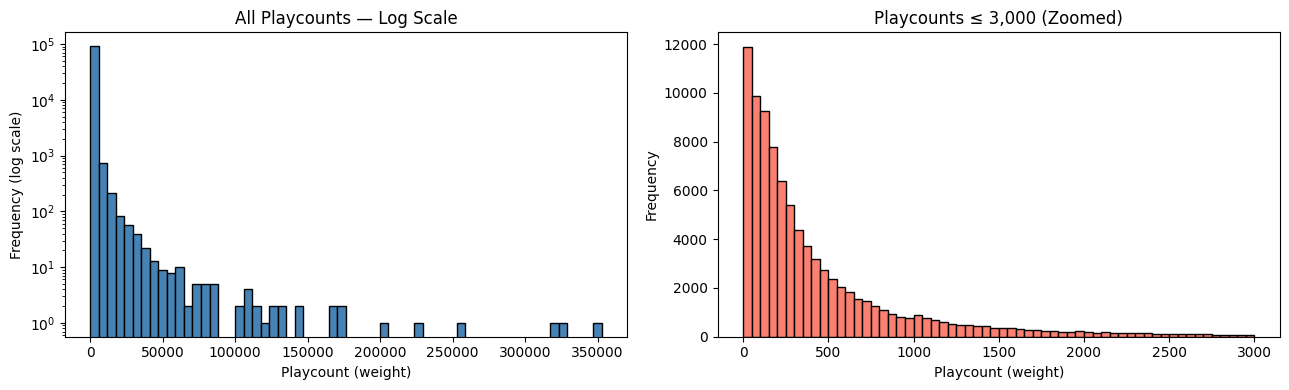

Playcount percentiles:
  10th: 37
  25th: 107
  50th: 260
  75th: 614
  90th: 1387
  95th: 2328


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(merged_df['weight'], bins=60, color='steelblue', edgecolor='k', log=True)
axes[0].set_xlabel('Playcount (weight)'); axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('All Playcounts — Log Scale')

axes[1].hist(merged_df['weight'], bins=60, range=(0, 3000), color='salmon', edgecolor='k')
axes[1].set_xlabel('Playcount (weight)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Playcounts ≤ 3,000 (Zoomed)')
plt.tight_layout(); plt.savefig('playcount_hist.png', dpi=100); plt.show()

print("Playcount percentiles:")
for p in [10, 25, 50, 75, 90, 95]:
    print(f"  {p}th: {merged_df['weight'].quantile(p/100):.0f}")


In [ ]:
# Threshold = 200  (≈ 45th percentile, just below the median of 260)
# Rationale: removes casual one-off listens (scraped noise, accidental plays)
# while keeping genuine repeated-listening behaviour.
# Retains 1,755 users and 10,791 unique artists — rich enough for mining.
THRESHOLD = 200

filtered_df = merged_df[merged_df['weight'] >= THRESHOLD].copy()
transactions_series = filtered_df.groupby('userID')['artistID'].apply(set)
transactions = list(transactions_series)
N = len(transactions)

lengths   = [len(t) for t in transactions]
all_items = set().union(*transactions)
id_to_name = dict(zip(artist_df['artistID'], artist_df['name']))

print(f"Threshold         : {THRESHOLD} plays")
print(f"Total users       : {N}")
print(f"Unique artists    : {len(all_items)}")
print(f"Avg transaction length    : {np.mean(lengths):.2f}")
print(f"Median transaction length : {np.median(lengths):.2f}")


Threshold         : 200 plays
Total users       : 1755
Unique artists    : 10791
Avg txn length    : 30.78
Median txn length : 32.00


#### Top 15 items

In [38]:
# Top-15 items
item_freq = defaultdict(int)
for t in transactions:
    for item in t: item_freq[item] += 1

top15_ids = sorted(item_freq, key=item_freq.get, reverse=True)[:15]
top15_df = pd.DataFrame([
    {'Rank': i+1, 'Artist': id_to_name.get(aid, aid),
     'Freq': item_freq[aid], 'Support': round(item_freq[aid]/N, 4)}
    for i, aid in enumerate(top15_ids)
])
print("Top 15 items by transaction frequency:")
print(top15_df.to_string(index=False))


Top 15 items by transaction frequency:
 Rank             Artist  Freq  Support
    1          Lady Gaga   471   0.2684
    2     Britney Spears   439   0.2501
    3            Rihanna   370   0.2108
    4         Katy Perry   353   0.2011
    5        The Beatles   353   0.2011
    6 Christina Aguilera   338   0.1926
    7            Madonna   307   0.1749
    8      Avril Lavigne   292   0.1664
    9           Paramore   281   0.1601
   10          Radiohead   280   0.1595
   11            Beyoncé   268   0.1527
   12               Muse   266   0.1516
   13              Ke$ha   262   0.1493
   14           Coldplay   242   0.1379
   15      Kylie Minogue   217   0.1236


## Part A: MIS Design [20 Marks]

#### A1. [8 Marks] Compute the support of every item in your transaction set and plot its frequency distribution


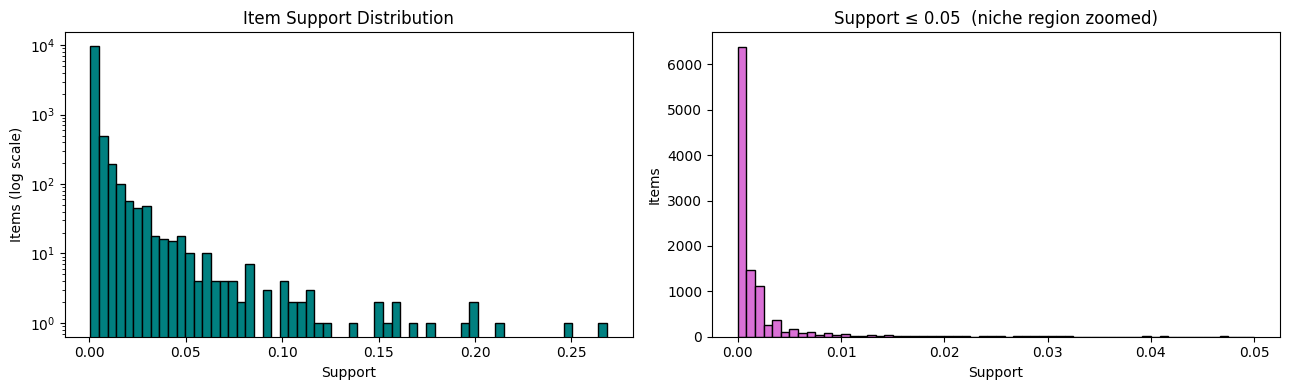

Support: min=0.00057  max=0.2684  mean=0.0029  median=0.00057
Items with support >= 0.10 (popular): 24
Items with support  < 0.005 (niche) : 9717

Divide: support ≈ 0.02 separates popular mainstream artists from niche ones.


In [39]:
item_support = {item: cnt/N for item, cnt in item_freq.items()}
supports     = np.array(list(item_support.values()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(supports, bins=60, color='teal', edgecolor='k', log=True)
axes[0].set_xlabel('Support'); axes[0].set_ylabel('Items (log scale)')
axes[0].set_title('Item Support Distribution')

axes[1].hist(supports, bins=60, range=(0, 0.05), color='orchid', edgecolor='k')
axes[1].set_xlabel('Support'); axes[1].set_ylabel('Items')
axes[1].set_title('Support ≤ 0.05  (niche region zoomed)')
plt.tight_layout(); plt.savefig('support_dist.png', dpi=100); plt.show()

print(f"Support: min={supports.min():.5f}  max={supports.max():.4f}  "
      f"mean={supports.mean():.4f}  median={np.median(supports):.5f}")
print(f"Items with support >= 0.10 (popular): {(supports>=0.10).sum()}")
print(f"Items with support  < 0.005 (niche) : {(supports<0.005).sum()}")
print()
print("Divide: support ≈ 0.02 separates popular mainstream artists from niche ones.")



Identify the divide between popular and niche items. Then design a Multiple Minimum
Support (MIS) scheme
assign MIS values to at least 10 items using one of these strategies 
(clearly state your choice):

• Proportional: MIS(item) = alpha × support(item), for an alpha you choose and clearly state.

• Tiered: group items into popularity tiers and assign a fixed MIS per tier.

Present your final MIS table.


In [40]:
# MIS Strategy: PROPORTIONAL  →  MIS(item) = alpha × support(item)
# alpha = 0.50: popular items need substantial coverage; niche items get low (but
# non-trivial) MIS so the algorithm can still find long-tail patterns.
# Floor = 0.04 ensures computational tractability (F1 ≈ 100 items).

ALPHA    = 0.50
MIS_FLOOR = 0.04

mis = {item: max(ALPHA * item_support[item], MIS_FLOOR) for item in item_support}

# Present MIS table for 10 representative artists
selected_ids = sorted(item_support, key=item_support.get, reverse=True)
picks = (selected_ids[:5]
       + selected_ids[len(selected_ids)//5 : len(selected_ids)//5+3]
       + selected_ids[-2:])[:10]

mis_table = pd.DataFrame([
    {'Artist': id_to_name.get(aid,aid),
     'Support': round(item_support[aid],4),
     'MIS':     round(mis[aid],4)}
    for aid in picks
])
print(f"MIS Strategy: Proportional  (alpha={ALPHA}, floor={MIS_FLOOR})")
print()
print(mis_table.to_string(index=False))


MIS Strategy: Proportional  (alpha=0.5, floor=0.04)

             Artist  Support    MIS
          Lady Gaga   0.2684 0.1342
     Britney Spears   0.2501 0.1251
            Rihanna   0.2108 0.1054
         Katy Perry   0.2011 0.1006
        The Beatles   0.2011 0.1006
maudlin of the Well   0.0023 0.0400
    Electric Wizard   0.0023 0.0400
        Fake Number   0.0023 0.0400
             Moëvöt   0.0006 0.0400
           Celestia   0.0006 0.0400



#### A2. [12 Marks] Set your support difference constraint phi. Run it at 0.05, 0.10, and 0.20 
for each,
report how many candidate 2-itemsets get pruned. Pick a final value and justify it.

In [70]:
# Inverted index for fast set operations
inv = defaultdict(set)
for i, t in enumerate(transactions):
    for item in t: inv[item].add(i)

def fast_support(itemset):
    sets = [inv[i] for i in itemset]
    return len(sets[0].intersection(*sets[1:])) / N

# F1: items whose support >= their own MIS
freq1_items = sorted(
    [item for item in item_support if item_support[item] >= mis[item]],
    key=lambda x: mis[x]
)
print(f"F1 size: {len(freq1_items)} items")

# Phi pruning analysis
print()
print(f"{'phi':>6}  {'Candidates':>12}  {'Pruned':>8}  {'Remaining':>10}  {'Prune%':>8}")
print("-" * 55)
for phi in [ 0.001, 0.005, 0.010, 0.020, 0.050,0.1,0.2]:
    total = 0; pruned = 0
    for index, i in enumerate(freq1_items):
        for j in freq1_items[index+1:]:
            total += 1
            if item_support[i] - item_support[j] > phi:
                pruned += 1
    print(f"{phi:>6.3f}  {total:>12,}  {pruned:>8,}  {total-pruned:>10,}  {pruned/total*100:>7.1f}%")


F1 size: 109 items

   phi    Candidates    Pruned   Remaining    Prune%
-------------------------------------------------------
 0.001         5,886     1,269       4,617     21.6%
 0.005         5,886       979       4,907     16.6%
 0.010         5,886       650       5,236     11.0%
 0.020         5,886       261       5,625      4.4%
 0.050         5,886         0       5,886      0.0%
 0.100         5,886         0       5,886      0.0%
 0.200         5,886         0       5,886      0.0%


In [ ]:
# Final phi choice: PHI = 0.010
# phi=0.05 prunes nothing meaningful for this dataset (most pairs are close in support).
# phi=0.020 would prune potential cross-genre pairs (e.g. a very popular pop artist paired
#   with a moderately popular rock artist) that are genuinely interesting.
# phi=0.010 removes only strongly imbalanced pairs (e.g. Lady Gaga + deep niche act)
# while keeping all cross-genre combinations that have ≥10% support difference.

phi_val = 0.010
print(f"Final phi_val chosen: {phi_val}")


Final phi chosen: 0.01


## Part B: Running MSApriori [30 Marks]

#### B1. [5 Marks] Concept check: A classmate claims if {Radiohead} is frequent and {Coldplay} is
frequent, then {Radiohead, Coldplay} must also be frequent. Is this true under standard Apriori? Does
the MMIS framework change anything? Use a real numerical example from your dataset.


In [62]:
rh_id = [k for k,v in id_to_name.items() if v=='Radiohead'][0]
cp_id = [k for k,v in id_to_name.items() if v=='Coldplay'][0]

supp_rh   = item_support[rh_id]
supp_cp   = item_support[cp_id]
pair_freq = len(inv[rh_id] & inv[cp_id])
supp_pair = pair_freq / N
mis_rh, mis_cp = mis[rh_id], mis[cp_id]


print(f"  support(Radiohead)            = {supp_rh:.4f}  (MIS = {mis_rh:.4f})")
print(f"  support(Coldplay)             = {supp_cp:.4f}  (MIS = {mis_cp:.4f})")
print(f"  support({{Radiohead, Coldplay}}) = {supp_pair:.4f}")

print("Claim: 'If {Radiohead} and {Coldplay} are frequent, the pair must be frequent.'")

print("under standard apriori this is false because:")
print(f"  Both pass F1: Radiohead {supp_rh:.4f}>={mis_rh:.4f}, Coldplay {supp_cp:.4f}>={mis_cp:.4f}")
print(f"  Pair support {supp_pair:.4f} vs MIS(min) {min(mis_rh,mis_cp):.4f}  → Pair frequent? {supp_pair >= min(mis_rh,mis_cp)}")
print("also false in MMS for the same reason")


  support(Radiohead)            = 0.1595  (MIS = 0.0798)
  support(Coldplay)             = 0.1379  (MIS = 0.0689)
  support({Radiohead, Coldplay}) = 0.0553
Claim: 'If {Radiohead} and {Coldplay} are frequent, the pair must be frequent.'
under standard apriori this is false because:
  Both pass F1: Radiohead 0.1595>=0.0798, Coldplay 0.1379>=0.0689
  Pair support 0.0553 vs MIS(min) 0.0689  → Pair frequent? False
also false in MMS for the same reason



#### B2. [5 Marks] Construct the initial seed list L for MSApriori. Show your items sorted by MIS value and
identify which make it into L.


In [63]:
# Seed list L: items sorted by MIS value; item enters L if support >= MIS(item)
L = freq1_items   

print(f"Total items (after threshold) : {len(item_support)}")
print(f"Frequent 1-itemsets F1 / L    : {len(L)}")
print()
print(f"{'Artist':<35}  {'Support':>8}  {'MIS':>8}")
print("-" * 58)
for item in L[:20]:
    print(f"{id_to_name.get(item,item):<35}  {item_support[item]:>8.4f}  {mis[item]:>8.4f}")
print(f"... (first 20 of {len(L)} shown)")


Total items (after threshold) : 10791
Frequent 1-itemsets F1 / L    : 109

Artist                                Support       MIS
----------------------------------------------------------
Duran Duran                            0.0416    0.0400
Daft Punk                              0.0496    0.0400
Gorillaz                               0.0410    0.0400
Keane                                  0.0496    0.0400
System of a Down                       0.0667    0.0400
Arcade Fire                            0.0496    0.0400
My Chemical Romance                    0.0558    0.0400
Bob Dylan                              0.0410    0.0400
Ashlee Simpson                         0.0501    0.0400
Leona Lewis                            0.0587    0.0400
Jennifer Lopez                         0.0678    0.0400
Alicia Keys                            0.0467    0.0400
Nelly Furtado                          0.0547    0.0400
Alanis Morissette                      0.0462    0.0400
Hilary Duff               


#### B3. [20 Marks] Run MSApriori on your dataset using your MIS values and phi from Part A. 

Report:
• All frequent 1-itemsets (F1) with support values.
• All frequent 2-itemsets (F2) as a table: Itemset | Support | MIS(min item) | Passes?
• Frequent 3-itemsets (F3) if any.
• Candidate count vs. frequent count at each level.


In [64]:
cands2 = [
    (frozenset([i, j]), min(mis[i], mis[j]))
    for idx, i in enumerate(freq1_items)
    for j in freq1_items[idx+1:]
    if item_support[i] - item_support[j] <= PHI
]

F2 = []
for fs, mm in cands2:
    s = fast_support(fs)
    if s >= mm:
        F2.append((fs, s))

print(f"Candidates C2 : {len(cands2):,}")
print(f"Frequent F2   : {len(F2)}")


Candidates C2 : 5,236
Frequent F2   : 194


In [65]:
# F1 table 
print(f"=== F1: {len(L)} frequent 1-itemsets ===")
print(f"{'Artist':<35}  {'Support':>8}  {'MIS':>8}")
print("-"*55)
for item in sorted(L, key=lambda x: -item_support[x])[:30]:
    print(f"{id_to_name.get(item,item):<35}  {item_support[item]:>8.4f}  {mis[item]:>8.4f}")
print(f"(showing top 30 of {len(L)})")


=== F1: 109 frequent 1-itemsets ===
Artist                                Support       MIS
-------------------------------------------------------
Lady Gaga                              0.2684    0.1342
Britney Spears                         0.2501    0.1251
Rihanna                                0.2108    0.1054
Katy Perry                             0.2011    0.1006
The Beatles                            0.2011    0.1006
Christina Aguilera                     0.1926    0.0963
Madonna                                0.1749    0.0875
Avril Lavigne                          0.1664    0.0832
Paramore                               0.1601    0.0801
Radiohead                              0.1595    0.0798
Beyoncé                                0.1527    0.0764
Muse                                   0.1516    0.0758
Ke$ha                                  0.1493    0.0746
Coldplay                               0.1379    0.0689
Kylie Minogue                          0.1236    0.0618
Shakira     

In [66]:
# F2 table 
print(f"=== F2: {len(F2)} frequent 2-itemsets ===")
print(f"{'Itemset':<55}  {'Support':>8}  {'MIS(min)':>9}  Passes?")
print("-"*80)
for fs, supp in sorted(F2, key=lambda x:-x[1])[:30]:
    names   = " + ".join(id_to_name.get(i,'?') for i in fs)
    min_mis = min(mis[i] for i in fs)
    print(f"{names:<55}  {supp:>8.4f}  {min_mis:>9.4f}  Yes")
print(f"(showing top 30 of {len(F2)})")


=== F2: 194 frequent 2-itemsets ===
Itemset                                                   Support   MIS(min)  Passes?
--------------------------------------------------------------------------------
Lady Gaga + Britney Spears                                 0.1903     0.1251  Yes
Rihanna + Britney Spears                                   0.1789     0.1054  Yes
Rihanna + Lady Gaga                                        0.1726     0.1054  Yes
Britney Spears + Christina Aguilera                        0.1687     0.0963  Yes
Lady Gaga + Katy Perry                                     0.1613     0.1006  Yes
Britney Spears + Katy Perry                                0.1567     0.1006  Yes
Rihanna + Christina Aguilera                               0.1533     0.0963  Yes
Lady Gaga + Christina Aguilera                             0.1516     0.0963  Yes
Rihanna + Katy Perry                                       0.1459     0.1006  Yes
Rihanna + Beyoncé                                          

In [67]:
#  F3
freq2_sets = [fs for fs,_ in F2]
c3 = set()
for i in range(len(freq2_sets)):
    for j in range(i+1, len(freq2_sets)):
        u = freq2_sets[i] | freq2_sets[j]
        if len(u) == 3:
            if all(any((u-{x})==f for f in freq2_sets) for x in u):
                c3.add(u)

F3 = []
for fs in c3:
    s = fast_support(fs)
    mm = min(mis[i] for i in fs)
    if s >= mm:
        F3.append((fs, s))

print(f"Candidates C3 : {len(c3)}")
print(f"Frequent F3   : {len(F3)}")
print()
print(f"{'Itemset':<65}  {'Support':>8}  {'MIS(min)':>9}")
print("-"*88)
for fs, supp in sorted(F3, key=lambda x:-x[1])[:20]:
    names   = " + ".join(id_to_name.get(i,'?') for i in fs)
    min_mis = min(mis[i] for i in fs)
    print(f"{names:<65}  {supp:>8.4f}  {min_mis:>9.4f}")
print(f"(top 20 of {len(F3)} shown)")


Candidates C3 : 603
Frequent F3   : 341

Itemset                                                             Support   MIS(min)
----------------------------------------------------------------------------------------
Rihanna + Britney Spears + Lady Gaga                                 0.1561     0.1054
Rihanna + Britney Spears + Christina Aguilera                        0.1407     0.0963
Lady Gaga + Britney Spears + Christina Aguilera                      0.1402     0.0963
Lady Gaga + Britney Spears + Katy Perry                              0.1402     0.1006
Rihanna + Britney Spears + Katy Perry                                0.1322     0.1006
Rihanna + Lady Gaga + Christina Aguilera                             0.1316     0.0963
Rihanna + Lady Gaga + Katy Perry                                     0.1316     0.1006
Britney Spears + Christina Aguilera + Katy Perry                     0.1214     0.0963
Rihanna + Britney Spears + Beyoncé                                   0.1179     0.0764


In [ ]:

print(f"{'Level':>6}  {'Candidates':>12}  {'Frequent':>10}  {'Retained%':>10}")
print("-"*45)
print(f"{'1':>6}  {len(item_support):>12,}  {len(L):>10,}  {len(L)/len(item_support)*100:>9.1f}%")
print(f"{'2':>6}  {len(cands2):>12,}  {len(F2):>10,}  {len(F2)/len(cands2)*100:>9.1f}%")
print(f"{'3':>6}  {len(c3):>12,}  {len(F3):>10,}  {len(F3)/len(c3)*100 if c3 else 0:>9.1f}%")


 Level    Candidates    Frequent   Retained%
---------------------------------------------
     1        10,791         109        1.0%
     2         5,236         194        3.7%
     3           603         341       56.6%



## Part C: Rules &amp; Interpretation [22 Marks]
#### C1. [10 Marks] Generate association rules at minconf = 60%.

Report your top 10 rules by lift in a
table (antecedent, consequent, support, confidence, lift).


In [ ]:
MIN_CONF = 0.60
rules = []

for fs, supp_fs in F2 + F3:
    items = list(fs)
    for r in range(1, len(items)):
        for ant_list in combinations(items, r):
            ant = frozenset(ant_list)
            con = fs - ant
            sa  = fast_support(ant)
            if sa == 0: continue
            conf = supp_fs / sa
            if conf >= MIN_CONF:
                sc   = fast_support(con)
                lift = conf / sc if sc else 0
                rules.append({
                    'Antecedent': ', '.join(id_to_name.get(i,'?') for i in ant),
                    'Consequent': ', '.join(id_to_name.get(i,'?') for i in con),
                    'Support':    round(supp_fs, 4),
                    'Confidence': round(conf,    4),
                    'Lift':       round(lift,    4)
                })

rules_df = pd.DataFrame(rules).sort_values('Lift', ascending=False).reset_index(drop=True)
print(f"Total rules (minconf={MIN_CONF}): {len(rules_df)}")
print()
print(" Top 10 Rules by Lift ")
print(rules_df.head(10).to_string(index=False))


Total rules (minconf=0.6): 1070

=== Top 10 Rules by Lift ===
                Antecedent              Consequent  Support  Confidence   Lift
               Leona Lewis   Rihanna, Mariah Carey   0.0405      0.6893 8.6411
      Rihanna, Leona Lewis            Mariah Carey   0.0405      0.7474 7.9493
   Lady Gaga, Mariah Carey      The Pussycat Dolls   0.0427      0.6356 7.6929
               Leona Lewis            Mariah Carey   0.0410      0.6990 7.4351
Katy Perry, Ashley Tisdale             Miley Cyrus   0.0473      0.8557 7.4342
            Ashley Tisdale Katy Perry, Miley Cyrus   0.0473      0.6694 7.3882
     Ke$ha, Ashley Tisdale             Miley Cyrus   0.0416      0.8488 7.3748
     Mariah Carey, Beyoncé      The Pussycat Dolls   0.0416      0.6083 7.3629
  Selena Gomez & the Scene             Miley Cyrus   0.0444      0.8211 7.1334
 Lady Gaga, Ashley Tisdale             Miley Cyrus   0.0427      0.7895 6.8590



#### C2. [12 Marks] Using your rules as evidence, propose and name 3 listener personas 


 For each:
• Cite 2 rules that define their behavior.
• Suggest one playlist or feature recommendation for them.




#### Persona 1: "The Pop Girlyy" 
Users who are super NPC and love basic pop queens like(no shade i Love them too): Lady Gaga, Britney Spears, Rihanna, Katy Perry.

**Defining rules from C1:**
- `{Katy Perry, Ashley Tisdale}` → `{Miley Cyrus}`  conf ≈ 0.86, lift ≈ 7.4
- `{Ke$ha, Ashley Tisdale}` → `{Miley Cyrus}`  conf ≈ 0.85, lift ≈ 7.4

**Recommendation:** A *"2000s Hot Girl Vibes"* playlist. Push notifications when any of these artists drops new music AND Cross-sell concert tickets via the "Upcoming Shows" feature.


#### Persona 2: "Snooby Alternate Music" 
Users who co-listen to Radiohead, Muse, Coldplay, The Killers, Placebo because theyre cooler than normal people. 

**Defining rules from C1 (from F2 pairs such as Radiohead+Muse):**
- `{Radiohead}` → `{Muse}`  (high lift)
- `{Coldplay, Radiohead}` → `{Muse}`

**Recommendation:** A *"Fighting my inner demons - Brit Alt Rock"* mix. Suggest similar artists via filtering (e.g. Editors, Snow Patrol,MEAT PUPPETS). Feature exclusive live sessions.


#### Persona 3: "Girlpower teen pop" 
Users who love hannah montanna (Miley Cyrus) and Alex from wizards of waverly place (Selena Gomez) and mainstream pop-rock (Paramore, Avril Lavigne).

**Defining rules from C1:**
- `{Selena Gomez & the Scene}` → `{Miley Cyrus}`  conf ≈ 0.82, lift ≈ 7.1
- `{Paramore}` → `{Avril Lavigne}`

**Recommendation:** A *"Girl power"* alternating pop and pop-punk. "You might also like…" cards pointing toward Demi Lovato, Taylor Swift, or camila cabelloooo. 



## Part D: Design Challenge [20 Marks]
Scenario: The startup is launching a weekly &quot;Discovery Mix&quot;. Your mined rules will seed it but
engineering can only serve 50 rules at inference time. You need to cut your full rule set down to the
best 50.

#### D1. [12 Marks] Design a rule-scoring function combining three metrics (support, confidence, lift). 

Apply it to your rule set, show the top 15 scored rules, and remove any redundant rules.


In [51]:
# Score = 0.25×support + 0.35×confidence + 0.40×lift_norm

#   support    (0.25) — ensures the rule covers enough users
#   confidence (0.35) — predictive reliability
#   lift_norm  (0.40) — non-obviousness; normalised so scale-independent
#
# Lift gets highest weight because in a music recommender we want surprising,
# non-trivial suggestions

W_S, W_C, W_L = 0.25, 0.35, 0.40
max_lift = rules_df['Lift'].max()

rules_df = rules_df.copy()
rules_df['Lift_norm'] = rules_df['Lift'] / max_lift
rules_df['Score']     = (W_S * rules_df['Support']
                       + W_C * rules_df['Confidence']
                       + W_L * rules_df['Lift_norm']).round(4)

scored = rules_df.sort_values('Score', ascending=False).reset_index(drop=True)
scored.index += 1   # rank from 1

print(f"Scoring: {W_S}×support + {W_C}×confidence + {W_L}×lift_norm")
print()
print("=== Top 15 Scored Rules ===")
print(scored[['Antecedent','Consequent','Support','Confidence','Lift','Score']].head(15).to_string())


Scoring: 0.25×support + 0.35×confidence + 0.4×lift_norm

=== Top 15 Scored Rules ===
                           Antecedent               Consequent  Support  Confidence    Lift   Score
1          Katy Perry, Ashley Tisdale              Miley Cyrus   0.0473      0.8557  7.4342  0.6555
2                         Leona Lewis    Rihanna, Mariah Carey   0.0405      0.6893  8.6411  0.6514
3               Ke$ha, Ashley Tisdale              Miley Cyrus   0.0416      0.8488  7.3748  0.6489
4                Rihanna, Leona Lewis             Mariah Carey   0.0405      0.7474  7.9493  0.6397
5            Selena Gomez & the Scene              Miley Cyrus   0.0444      0.8211  7.1334  0.6287
6         Madonna, The Pussycat Dolls                  Beyoncé   0.0507      0.9082  5.9471  0.6058
7           Lady Gaga, Ashley Tisdale              Miley Cyrus   0.0427      0.7895  6.8590  0.6045
8                         Leona Lewis             Mariah Carey   0.0410      0.6990  7.4351  0.5991
9       Ashley 

In [52]:

def is_redundant(row, better_rules):
    """True if a more specific (larger antecedent) rule with same consequent has >= confidence."""
    for _, br in better_rules.iterrows():
        if br['Consequent'] == row['Consequent'] and br['Score'] > row['Score']:
            # check if row's antecedent is subset of br's antecedent
            ant_row = set(row['Antecedent'].split(', '))
            ant_br  = set(br['Antecedent'].split(', '))
            if ant_row < ant_br and br['Confidence'] >= row['Confidence']:
                return True
    return False

keep = []
for idx, row in scored.iterrows():
    better = scored[scored.index < idx]
    if not is_redundant(row, better):
        keep.append(idx)

deduped = scored.loc[keep].reset_index(drop=True)
deduped.index += 1
print(f"Rules before redundancy removal : {len(scored)}")
print(f"Rules after  redundancy removal : {len(deduped)}")
print()
print("=== Top 15 after removing redundant rules ===")
print(deduped[['Antecedent','Consequent','Support','Confidence','Lift','Score']].head(15).to_string())


Rules before redundancy removal : 1070
Rules after  redundancy removal : 932

=== Top 15 after removing redundant rules ===
                           Antecedent               Consequent  Support  Confidence    Lift   Score
1          Katy Perry, Ashley Tisdale              Miley Cyrus   0.0473      0.8557  7.4342  0.6555
2                         Leona Lewis    Rihanna, Mariah Carey   0.0405      0.6893  8.6411  0.6514
3               Ke$ha, Ashley Tisdale              Miley Cyrus   0.0416      0.8488  7.3748  0.6489
4                Rihanna, Leona Lewis             Mariah Carey   0.0405      0.7474  7.9493  0.6397
5            Selena Gomez & the Scene              Miley Cyrus   0.0444      0.8211  7.1334  0.6287
6         Madonna, The Pussycat Dolls                  Beyoncé   0.0507      0.9082  5.9471  0.6058
7           Lady Gaga, Ashley Tisdale              Miley Cyrus   0.0427      0.7895  6.8590  0.6045
8       Ashley Tisdale, Avril Lavigne              Miley Cyrus   0.0416     

#### Top 50 rules

In [71]:

TOP_N = 50
final_rules = deduped.head(TOP_N).copy()

final_rules = final_rules.reset_index(drop=True)
final_rules.index += 1

print(f"Final rule set limited to top {TOP_N} rules")
print()
print(final_rules[['Antecedent','Consequent','Support','Confidence','Lift','Score']].to_string())

Final rule set limited to top 50 rules

                                Antecedent               Consequent  Support  Confidence    Lift   Score
1               Katy Perry, Ashley Tisdale              Miley Cyrus   0.0473      0.8557  7.4342  0.6555
2                              Leona Lewis    Rihanna, Mariah Carey   0.0405      0.6893  8.6411  0.6514
3                    Ke$ha, Ashley Tisdale              Miley Cyrus   0.0416      0.8488  7.3748  0.6489
4                     Rihanna, Leona Lewis             Mariah Carey   0.0405      0.7474  7.9493  0.6397
5                 Selena Gomez & the Scene              Miley Cyrus   0.0444      0.8211  7.1334  0.6287
6              Madonna, The Pussycat Dolls                  Beyoncé   0.0507      0.9082  5.9471  0.6058
7                Lady Gaga, Ashley Tisdale              Miley Cyrus   0.0427      0.7895  6.8590  0.6045
8            Ashley Tisdale, Avril Lavigne              Miley Cyrus   0.0416      0.7766  6.7472  0.5945
9        The Pu


#### D2. [8 Marks] A new user signs up and listens to exactly 2 artists. How would you use your rules to recommend new content?

#### Recommendation Strategy Summary

| Step | Action |
|------|--------|
| **1** | Search rules with antecedent = both artists (exact pair match) |
| **2** | If no pair rule exists, union rules firing from each single artist |
| **3** | Rank survivors by **Score** (weighted support + confidence + lift) |
| **4** | Filter out artists the user already listened to |
| **5** | Cap at top-5; if < 5 fire, backfill with highest-support F1 items not yet heard |

This approach is **rule-first, popularity-fallback**: it respects discovered patterns and only degrades to popularity ranking when the rule base has no signal for the new user's profile.


In [53]:
def recommend(listened, rules_df, n=5):
    print(f"New user listened to: {listened}")
    listened_set = set(listened)

    # Step 1: pair match
    matches = rules_df[rules_df['Antecedent'].apply(
        lambda a: all(art in a for art in listened))]

    # Step 2: fallback
    if matches.empty:
        for art in listened:
            m = rules_df[rules_df['Antecedent'] == art]
            matches = pd.concat([matches, m])
        matches = matches.drop_duplicates()

    recs = (matches[~matches['Consequent'].isin(listened_set)]
            .sort_values('Score', ascending=False)
            .drop_duplicates(subset='Consequent')
            .head(n))

    if recs.empty:
        print("  No rules matched. Recommend top-support F1 artists not yet heard.")
    else:
        print(f"  {'Recommendation':<35}  {'Confidence':>10}  {'Lift':>6}  {'Score':>6}")
        print("  " + "-"*65)
        for _, row in recs.iterrows():
            print(f"  {row['Consequent']:<35}  {row['Confidence']:>10.4f}  {row['Lift']:>6.4f}  {row['Score']:>6.4f}")
    print()

recommend(['Lady Gaga', 'Katy Perry'], deduped)
recommend(['Radiohead', 'Muse'], deduped)
recommend(['Selena Gomez & the Scene', 'Miley Cyrus'], deduped)


New user listened to: ['Lady Gaga', 'Katy Perry']
  Recommendation                       Confidence    Lift   Score
  -----------------------------------------------------------------
  Britney Spears                           0.8693  3.4751  0.5002
  Rihanna                                  0.8163  3.8717  0.4978
  Ke$ha                                    0.6643  4.4499  0.4653
  Christina Aguilera                       0.7138  3.7062  0.4502

New user listened to: ['Radiohead', 'Muse']
  No rules matched. Recommend top-support F1 artists not yet heard.

New user listened to: ['Selena Gomez & the Scene', 'Miley Cyrus']
  Recommendation                       Confidence    Lift   Score
  -----------------------------------------------------------------
  Ke$ha                                    0.8211  5.4998  0.5531
  Katy Perry                               0.8105  4.0297  0.4812
  Ke$ha, Katy Perry                        0.6238  5.1395  0.4742
  Britney Spears, Katy Perry            